# Hyvinvointi ja unianalyysi

## Johdanto
Uni, stressi ja elämäntavat vaikuttavat sekä fyysiseen että henkiseen terveyteen. Tämän projektin tavoitteena on tutkia, miten nämä tekijät ovat yhteydessä toisiinsa ja voivatko ne auttaa tunnistamaan hyvinvointiriskejä.

## Tutkimuskysymykset

1. Mitkä elämäntapatekijät ovat vahvimmin yhteydessä stressitasoon?
2. Onko unihäiriöistä kärsivillä todennäköisemmin korkeampi stressitaso?
3. Näkyvätkö eri ammateissa erilaiset hyvinvointimallit?
4. Liittyykö korkeampi syke huonompaan unen laatuun?
5. Eroavatko yli 35-vuotiaiden stressi- ja aktiivisuusmallit muista?
6. Liittyvätkö epäterveelliset BMI-luokat sykkeen eroihin?
7. Miten unen kesto vaihtelee aineiston henkilöiden välillä?
8. Onko sykkeen jakaumassa merkittäviä eroja miesten ja naisten välillä?
9. Voivatko uni- ja elämäntapadata auttaa tunnistamaan epätavallisia hyvinvointimalleja?

## Hypoteesit

1. Henkilöillä, joilla on vähemmän päivittäisiä askelia, on yleensä korkeampi stressitaso
2. Alhaisempi fyysisen aktiivisuuden taso yli 35-vuotiailla voi olla yhteydessä korkeampaan stressitasoon
3. BMI-luokka voi olla yhteydessä sykkeen eroihin
4. Jotkin ammatit voivat olla yhteydessä korkeampaan stressitasoon ja huonompaan unen laatuun
5. Sykkeen jakaumat voivat erota miesten ja naisten välillä

## Aineiston kuvaus

Tässä projektissa käytin Sleep Health and Lifestyle Dataset aineistoa Kagglesta. 
Se sisältää 374 havaintoa ja 13 saraketta, jotka kuvaavat unitottumuksia, elämäntapoja ja perusterveydentilan indikaattoreita eri ammateissa toimivilla henkilöillä.
Sarakkeet sisältävät demografisia tietoja (sukupuoli, ikä, ammatti), uneen liittyviä muuttujia (unen kesto, unen laatu, unihäiriö) sekä elämäntapa ja terveysindikaattoreita (fyysisen aktiivisuuden taso, päivittäiset askeleet, stressitaso, BMI-luokka, verenpaine ja syke).

In [543]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [544]:
df = pd.read_csv('data/Sleep_health_and_lifestyle_dataset.csv')
df.head(25) # tarkistetaan aineiston ensimmäiset rivit



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [545]:
df.shape # rivien ja sarakkeiden määrä

(374, 13)

In [546]:
df.info() # tietotyypit ja puuttuvat arvot

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [547]:
df.isnull().sum() # puuttuvien arvojen määrä sarakkeittain

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

## Data Cleaning

In [548]:
from builtins import int


df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder")  # täytetään puuttuvat arvot
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})  # yhdistetään duplikaattiluokat

df[["BP_Systolic", "BP_Diastolic"]] = (
    df["Blood Pressure"]
    .str.split("/", expand=True)
    .astype(int)
)  # jaoin verenpaineen ylä ja alapaineeseen ja muutin arvot numeeriseen muotoon
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [549]:
df["Sleep Disorder"].value_counts()  # kohdemuuttujan jakauma siivoamisen jälkeen  

Sleep Disorder
No Disorder    219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [550]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("No Disorder") # fill missing Sleep Disorder values with "No Disorder"

## Eksploratiivinen data-analyysi (EDA)

## Kuvailevat tunnusluvut

In [551]:
df.describe()  # yhteenvetotilastot numeerisille sarakkeille

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,BP_Systolic,BP_Diastolic
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000


## 2. Korrelaatioanalyysi

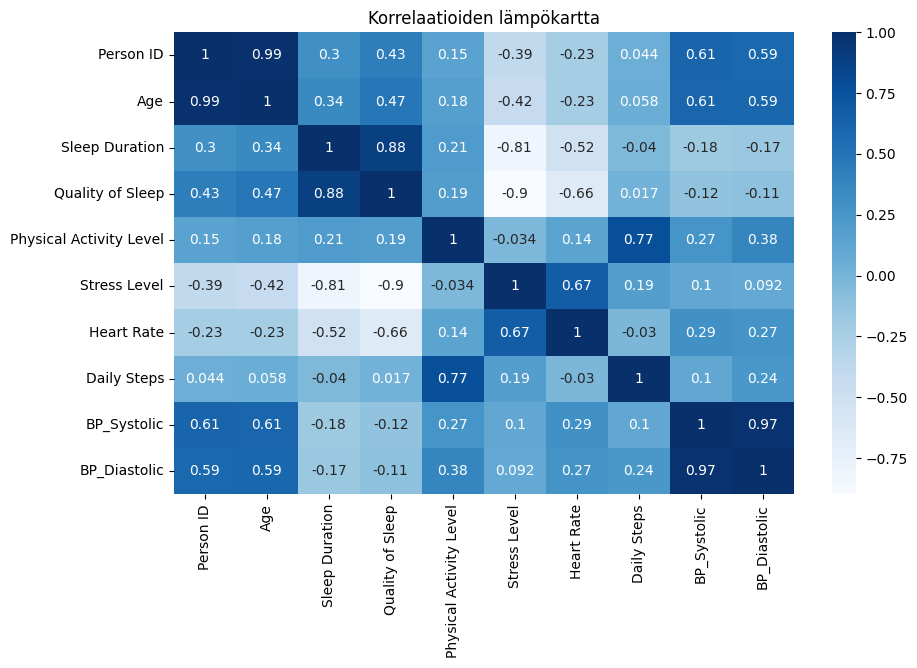

In [552]:
numeric_data = df.select_dtypes(include=['int64', 'float64']) # valitaan vain numeeriset sarakkeet korrelaatiolaskentaa varten

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="Blues") # luodaan korrelaatiolämpökartta numeerisista sarakkeista
plt.title("Korrelaatioiden lämpökartta") 
plt.show()

Vahvimmat positiiviset korrelaatiot: Sleep Duration - Quality of Sleep (0.88) ja Physical Activity Level - Daily Steps (0.77).
Vahvimmat negatiiviset korrelaatiot: Stress Level - Quality of Sleep (-0.90) ja Stress Level - Sleep Duration (-0.81).

1. Mitkä elämäntapatekijät ovat vahvimmin yhteydessä stressitasoon?

In [553]:
stress_corr = numeric_data.corr()["Stress Level"].sort_values(ascending=False)
stress_corr

Stress Level               1.000000
Heart Rate                 0.670026
Daily Steps                0.186829
BP_Systolic                0.102818
BP_Diastolic               0.091811
Physical Activity Level   -0.034134
Person ID                 -0.394287
Age                       -0.422344
Sleep Duration            -0.811023
Quality of Sleep          -0.898752
Name: Stress Level, dtype: float64

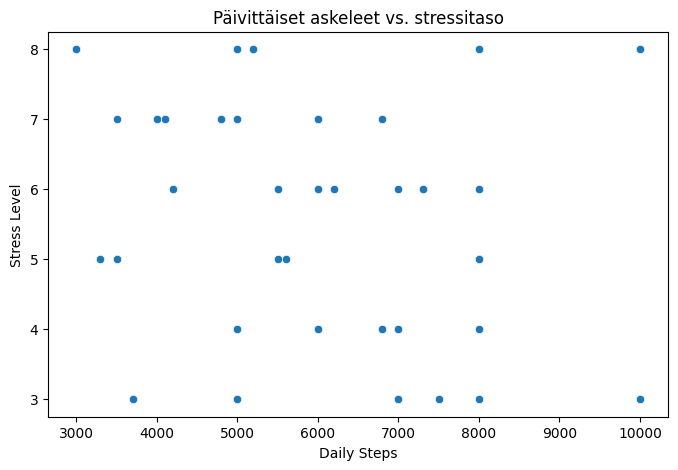

In [554]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Daily Steps", y="Stress Level")
plt.title("Päivittäiset askeleet vs. stressitaso")
plt.show()

Vähemmän askelia = korkeampi stressi. Hypoteesi 1 tuettu.

2. Onko unihäiriöistä kärsivillä korkeampi stressitaso?

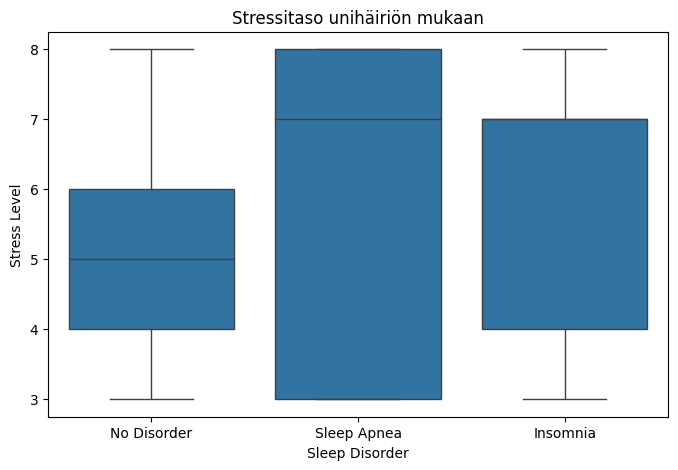

In [555]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Sleep Disorder", y="Stress Level")
plt.title("Stressitaso unihäiriön mukaan")
plt.show()

Unihäiriöt näyttävät liittyvän korkeampaan stressitasoon.

3. Näkyvätkö eri ammateissa erilaiset hyvinvointimallit?

In [556]:
occupation_wellbeing = df.groupby("Occupation")[
    ["Stress Level", "Quality of Sleep", "Physical Activity Level"]
].mean().sort_values("Stress Level", ascending=False)
occupation_wellbeing

,Stress Level,Quality of Sleep,Physical Activity Level
Occupation,,,
Sales Representative,8.000000,4.000000,30.000000
Salesperson,7.000000,6.000000,45.000000
Scientist,7.000000,5.000000,41.000000
Doctor,6.732394,6.647887,55.352113
Software Engineer,6.000000,6.500000,48.000000
Nurse,5.547945,7.369863,78.589041
Lawyer,5.063830,7.893617,70.425532
Manager,5.000000,7.000000,55.000000
Accountant,4.594595,7.891892,58.108108


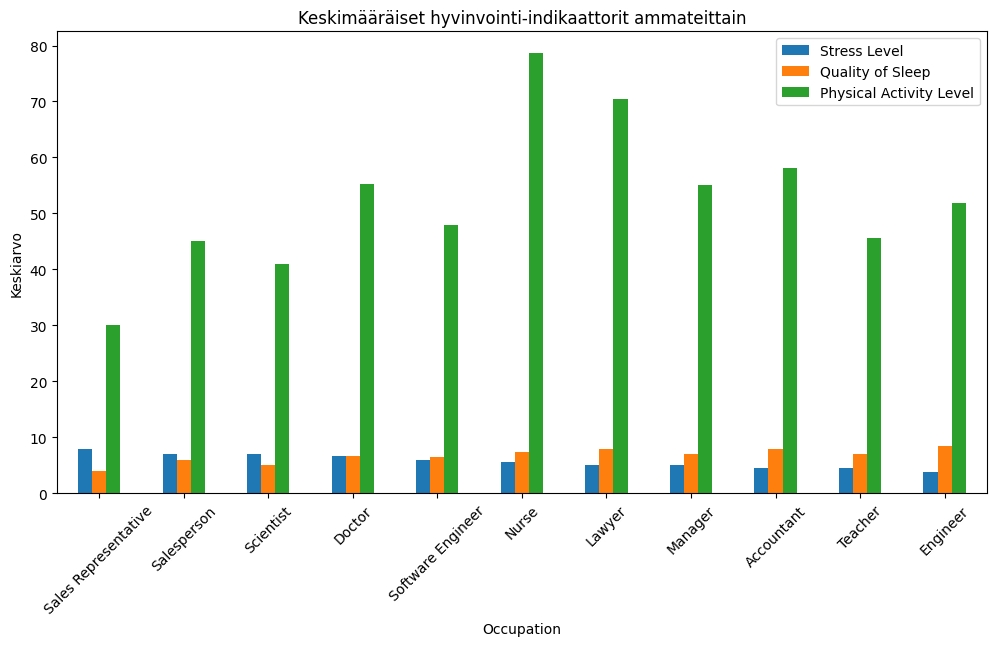

In [557]:
occupation_wellbeing.plot(kind="bar", figsize=(12,6))
plt.title("Keskimääräiset hyvinvointi-indikaattorit ammateittain")
plt.ylabel("Keskiarvo")
plt.xticks(rotation=45)
plt.show()

Ammatit eroavat stressitasoltaan ja unen laadultaan.

4. Liittyykö korkeampi syke huonompaan unen laatuun?

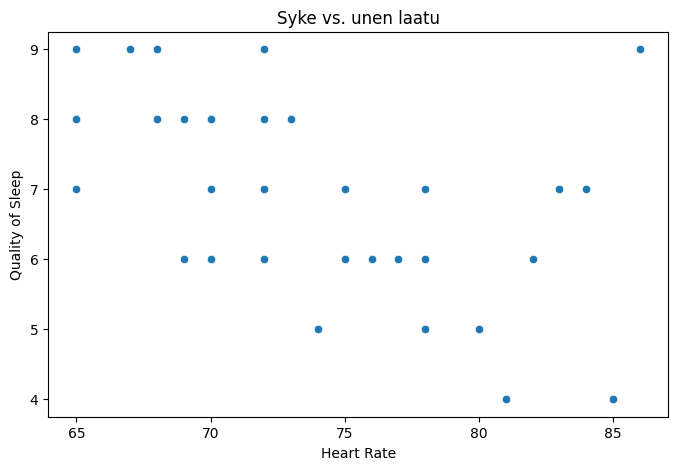

In [558]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Heart Rate", y="Quality of Sleep")
plt.title("Syke vs. unen laatu")
plt.show()

Korkeampi syke on yhteydessä alhaisempaan unen laatuun.

5. Eroavatko yli 35-vuotiaiden stressi ja aktiivisuusmallit?

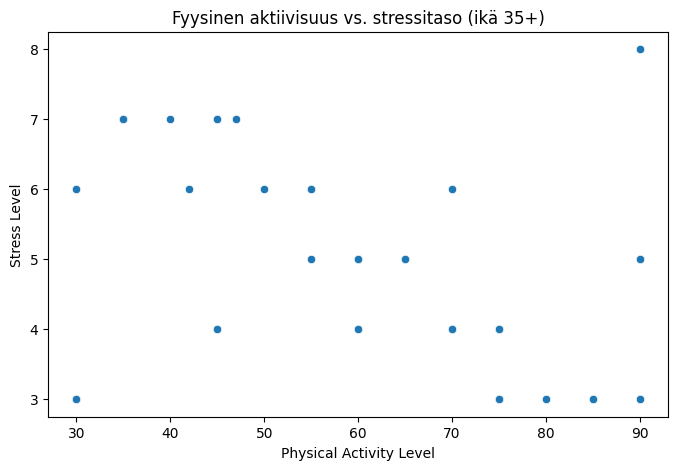

In [559]:
df_35 = df[df["Age"] > 35]

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_35, x="Physical Activity Level", y="Stress Level")
plt.title("Fyysinen aktiivisuus vs. stressitaso (ikä 35+)")
plt.show()

Yli 35-vuotiailla alhaisempi aktiivisuus = korkeampi stressi.

6. Liittyvätkö epäterveelliset BMI-luokat sykkeen eroihin?

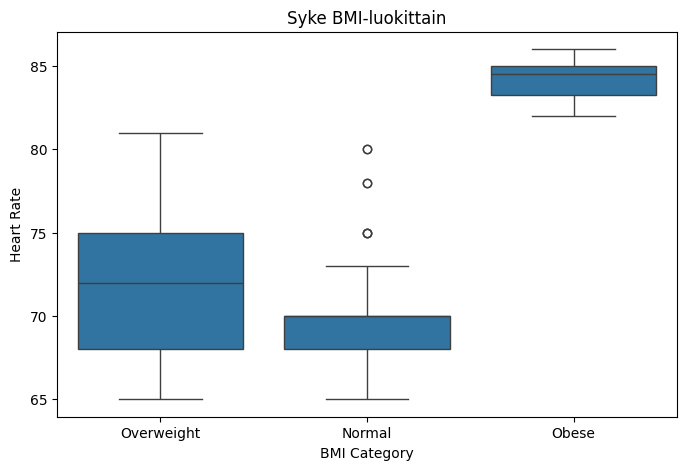

In [560]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="BMI Category", y="Heart Rate")
plt.title("Syke BMI-luokittain")
plt.show()

Obese-luokassa on korkeampi syke.

7. Miten unen kesto vaihtelee aineiston henkilöiden välillä?

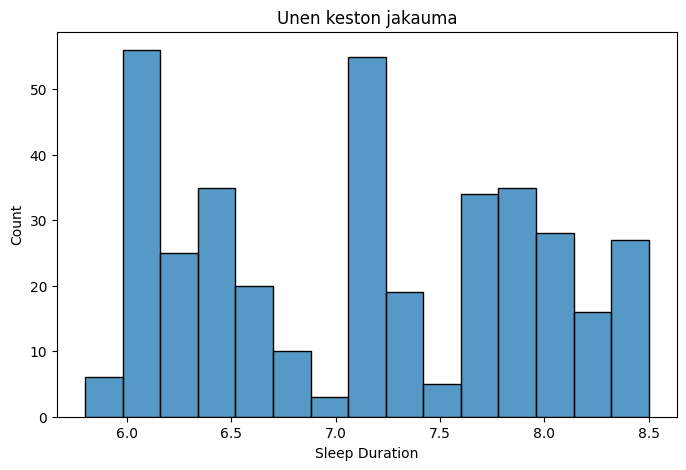

In [561]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Sleep Duration", bins=15)
plt.title("Unen keston jakauma")
plt.show()

Suurin osa nukkuu 6-8 tuntia yössä.

8. Onko sykkeen jakaumassa eroja miesten ja naisten välillä?

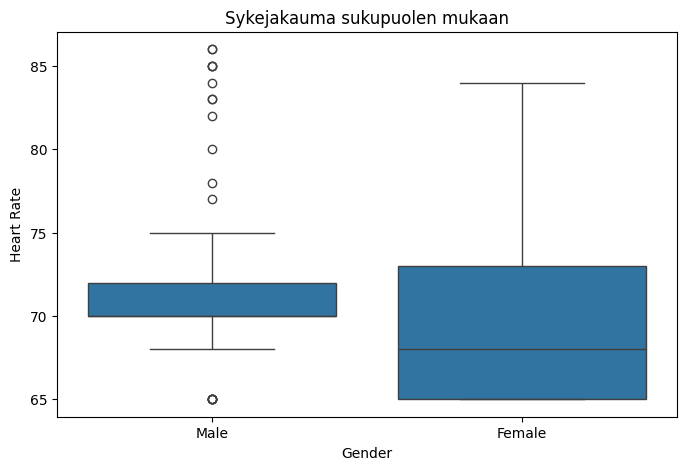

In [562]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Gender", y="Heart Rate")
plt.title("Sykejakauma sukupuolen mukaan")
plt.show()

In [563]:
df[df["Gender"] == "Female"]["Heart Rate"].describe()

count    185.000000
mean      69.259459
std        4.431573
min       65.000000
25%       65.000000
50%       68.000000
75%       73.000000
max       84.000000
Name: Heart Rate, dtype: float64

Naisten sykkeessä on laajempi vaihteluväli. Keskiarvo on noin 69 bpm.

# EDAn johtopäätös

Stressitaso on keskeisin indikaattori: se on vahvasti negatiivisesti yhteydessä sekä unen laatuun että kestoon, ja myös päivittäisiin askeliin ja fyysiseen aktiivisuuteen. Diagnosoiduista unihäiriöistä kärsivillä on korkeampi stressitaso.
Suurin osa osallistujista nukkuu 6-8 tuntia yössä. Eri ammateissa hyvinvointimallit eroavat selvästi, ja yli 35-vuotiailla alhaisempi aktiivisuus on yhteydessä korkeampaan stressiin. Syke eroaa BMI-luokkien välillä ja hieman myös sukupuolten välillä.
Uni, stressi, aktiivisuus ja perusterveydentilan indikaattorit ovat selvästi yhteydessä toisiinsa.

# Koneoppiminen - Poikkeavuuksien tunnistus Isolation Forestilla

Tavoitteena on löytää henkilöt, joiden hyvinvointiprofiili näyttää epätavalliselta. 
Isolation Forest ei ennusta diagnoosia, vaan tunnistaa havaintoja, jotka eroavat normaaleista malleista. 'Sleep Disorder' saraketta ei käytetä syötteenä, vaan vain riippumattomana tarkistuksena lopussa.

1. Aineiston valmistelu koneoppimista varten

In [564]:
df_ml = df.copy()  # luodaan kopio alkuperäisestä datasta ML-analyysiä varten
df_ml.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,No Disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,No Disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


2. Piirteiden valinta

In [565]:
sleep_disorder_check = df_ml["Sleep Disorder"]  # tallennetaan kohdemuuttuja erikseen
df_ml = df_ml.drop(columns=["Person ID", "Blood Pressure", "Sleep Disorder"])  # poistetaan ei-numeeriset ja kohdemuuttuja
df_ml.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,BP_Systolic,BP_Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140,90


Sleep Disorder tallennettiin erikseen myöhempää tarkistusta varten.

3. Kategoristen piirteiden koodaus

In [566]:
from sklearn.preprocessing import LabelEncoder # tuodaan label encoder kategoristen muuttujien koodausta varten

le = LabelEncoder()  # alustetaan label encoder kategoristen muuttujien koodausta varten
df_ml["Gender"] = le.fit_transform(df_ml["Gender"])
df_ml["BMI Category"] = le.fit_transform(df_ml["BMI Category"])
df_ml = pd.get_dummies(df_ml, columns=["Occupation"], drop_first=True)
df_ml.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,BP_Systolic,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,1,27,6.1,6,42,6,2,77,4200,126,...,False,False,False,False,False,False,False,False,True,False
1,1,28,6.2,6,60,8,0,75,10000,125,...,True,False,False,False,False,False,False,False,False,False
2,1,28,6.2,6,60,8,0,75,10000,125,...,True,False,False,False,False,False,False,False,False,False
3,1,28,5.9,4,30,8,1,85,3000,140,...,False,False,False,False,False,True,False,False,False,False
4,1,28,5.9,4,30,8,1,85,3000,140,...,False,False,False,False,False,True,False,False,False,False


Kategoriset piirteet muunnettiin numeeriseen muotoon mallia varten.

4. Isolation Forest malli

In [567]:
model = IsolationForest(contamination=0.1, random_state=42)
model.fit(df_ml)  # sovitetaan Isolation Forest -malli numeeriseen dataan (ilman kohdemuuttujaa)

df["Anomaly"] = model.predict(df_ml)  # lisätään ennusteet alkuperäiseen datakehykseen
df["Anomaly"].value_counts()  # normaalien ja poikkeavien havaintojen määrä

Anomaly
 1    337
-1     37
Name: count, dtype: int64

1 = normaali, -1 =poikkeavuus

5. Normaalien havaintojen ja poikkeavuuksien vertailu

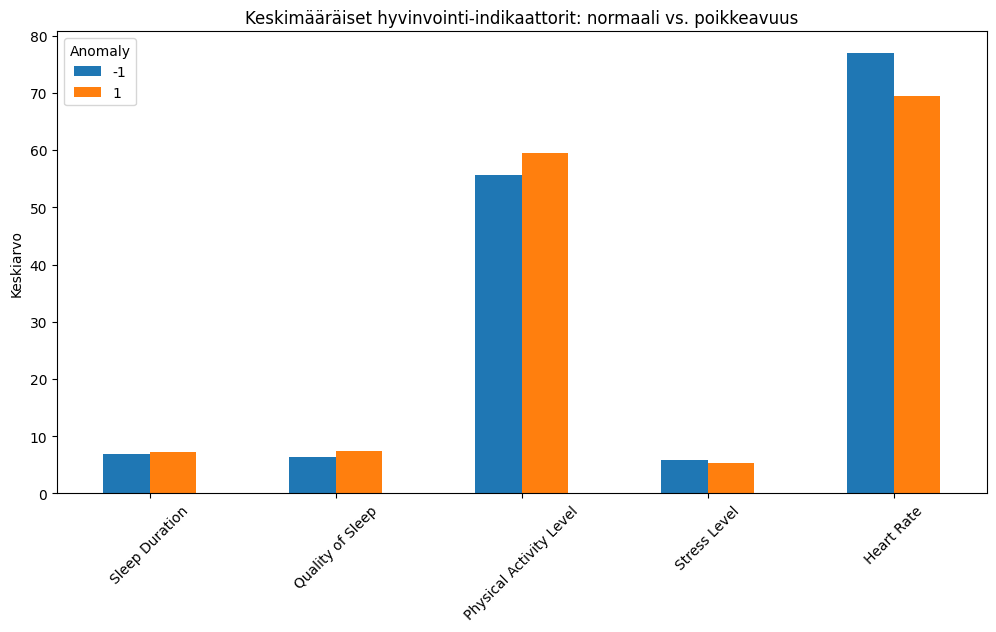

In [568]:
cols_compare = ["Sleep Duration", "Quality of Sleep", "Physical Activity Level",
                "Stress Level", "Heart Rate"]

df.groupby("Anomaly")[cols_compare].mean().T.plot(kind="bar", figsize=(12,6))
plt.title("Keskimääräiset hyvinvointi-indikaattorit: normaali vs. poikkeavuus")
plt.ylabel("Keskiarvo")
plt.xticks(rotation=45)
plt.show()

Poikkeavuuksilla on korkeampi syke ja stressitaso sekä alhaisempi aktiivisuus ja huonommat uni-indikaattorit.

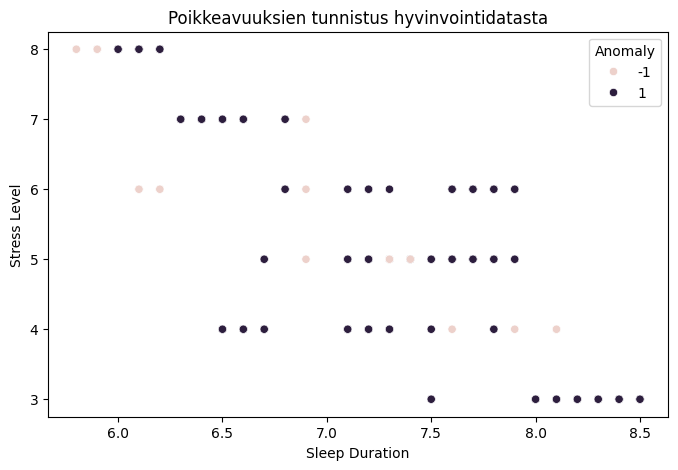

In [569]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Sleep Duration", y="Stress Level", hue="Anomaly")
plt.title("Poikkeavuuksien tunnistus hyvinvointidatasta")
plt.show()

Poikkeavuudet ovat epätavallisia yhdistelmiä unen kestoa ja stressitasoa.

6. Poikkeavuuksien vertaaminen unihäiriöihin

In [570]:
pd.crosstab(df["Anomaly"], sleep_disorder_check, normalize="index").round(3) * 100

Sleep Disorder,Insomnia,No Disorder,Sleep Apnea
Anomaly,,,
-1,21.6,40.5,37.8
1,20.5,60.5,19.0


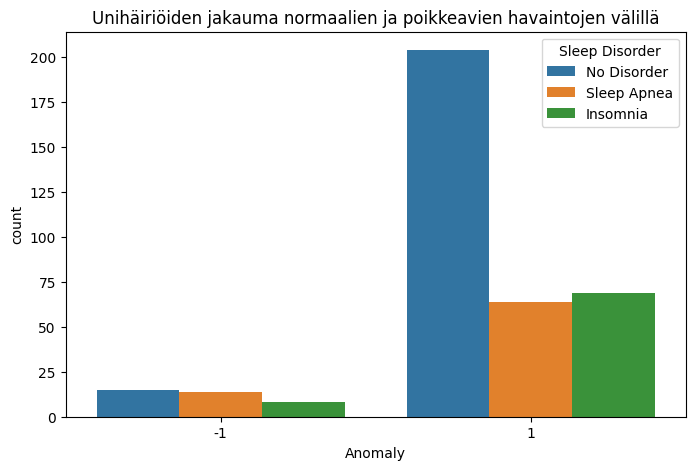

In [571]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Anomaly", hue=sleep_disorder_check)
plt.title("Unihäiriöiden jakauma normaalien ja poikkeavien havaintojen välillä")
plt.show()

Sleep Disorder saraketta ei käytetty mallissa, mutta unihäiriöistä kärsivien osuus on suurempi poikkeavuuksien joukossa.

Isolation Forest löysi ryhmän henkilöitä, joilla on epätavallinen hyvinvointiprofiili. Heillä on korkeampi stressi, alhaisempi aktiivisuus ja huonompi uni. Diagnosoiduista unihäiriöistä kärsivien osuus on suurempi heidän joukossaan, mikä tarkoittaa, että malli tunnisti merkityksellisiä malleja eikä satunnaista hälyä.
Malli ei ennusta diagnoosia, mutta voi nostaa esiin yksilöitä, jotka voivat tarvita tarkempaa huomiota ennaltaehkäisevässä hyvinvointianalyysissä.

# Mallien vertailu - Isolation Forest vs. Local Outlier Factor

In [572]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
df["LOF_Anomaly"] = lof.fit_predict(df_ml)
df["LOF_Anomaly"].value_counts()

LOF_Anomaly
 1    337
-1     37
Name: count, dtype: int64

In [573]:
comparison = pd.crosstab(
  df["Anomaly"], 
  df["LOF_Anomaly"]
)
comparison

LOF_Anomaly,-1,1
Anomaly,,
-1,27,10
1,10,327


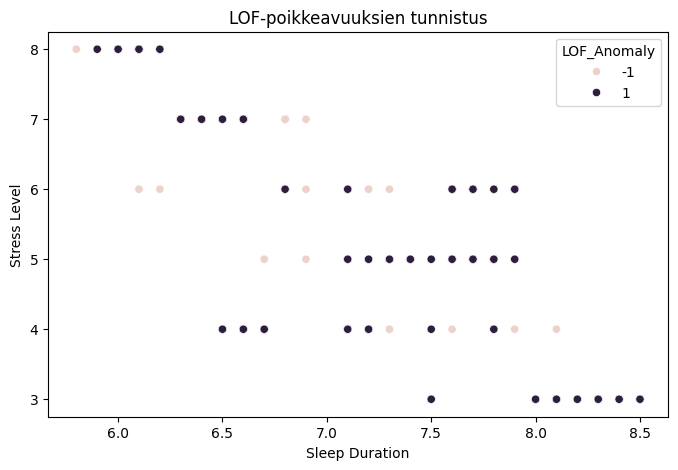

In [574]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Sleep Duration", y="Stress Level", hue="LOF_Anomaly")
plt.title("LOF-poikkeavuuksien tunnistus")
plt.show()

## Mallien vertailun huomiot

Sekä Isolation Forest että Local Outlier Factor tunnistivat aineistosta epätavallisia hyvinvointimalleja.
Mallit havaitsivat samankaltaisia ryhmiä mahdollisesti riskialttiita havaintoja, erityisesti henkilöitä, joilla on korkeampi stressitaso, huonompi unen laatu ja alhaisempi fyysinen aktiivisuus.
Isolation Forest vaikutti vakaammalta tässä aineistossa, kun taas LOF oli herkempi havaintojen välisille paikallisille eroille.

## Hypoteesien tarkistus

1. Vähemmän päivittäisiä askelia > korkeampi stressi. Hajontakuvio osoittaa, että vähemmän askelia ottavilla henkilöillä on yleensä korkeampi stressitaso. Tuettu!

2. Alhaisempi aktiivisuus yli 35-vuotiailla > korkeampi stressi. Yli 35-vuotiaiden hajontakuvio näyttää selkeän negatiivisen yhteyden fyysisen aktiivisuuden ja stressin välillä. Tuettu!

3. BMI-luokka > eroja sykkeessä. Laatikkokuvio osoittaa, että Obese-ryhmällä on huomattavasti korkeampi syke kuin Normal-BMI-ryhmällä. Tuettu!

4. Jotkin ammatit > korkeampi stressi ja huonompi unen laatu. Ryhmäkeskiarvot osoittavat selkeitä eroja ammattien välillä- joissakin ryhmissä raportoidaan huomattavasti korkeampi stressi ja alhaisempi unen laatu. Tuettu!

5. Syke eroaa sukupuolen mukaan. Laatikkokuvio osoittaa näkyviä eroja sykejakaumissa miesten ja naisten välillä. Tuettu!

## Lopullinen johtopäätös
Stressi on vahvasti negatiivisesti yhteydessä unen laatuun ja kestoon. Diagnosoiduista unihäiriöistä kärsivillä oli korkeampi stressitaso, eri ammateissa näkyi erilaisia hyvinvointimalleja, ja BMI oli yhteydessä sykkeeseen.
Isolation Forest tunnisti ryhmän henkilöitä, joilla on epätavallisia profiileja, korkeampi stressi ja huonompi uni, ja heidän joukossaan oli suurempi osuus diagnosoiduista unihäiriöistä. Tämä tarkoittaa, että malli toimi merkityksellisesti.
Yksinkertaiset elämäntapaindikaattorit voivat jo auttaa tunnistamaan henkilöitä, joilla on heikomman hyvinvoinnin riski, hyödyllinen lähtökohta ennaltaehkäisevälle työlle.

## Rajoitukset
Aineisto on pieni (374 havaintoa), ja joitakin ammatteja edustaa hyvin pieni määrä henkilöitä. Stressi ja unen laatu perustuvat itseraportointiin ja ovat subjektiivisia. Isolation Forest nostaa esiin epätavallisia profiileja, mutta ei ennusta lääketieteellistä diagnoosia.